In [1]:
import yaml
from ultralytics import YOLO
from torch.cuda import is_available

import os
import sys
sys.path.append(os.path.abspath('..'))

from src.model_utils import smart_predict
from src.generate_report import generate_report

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
s1_data = r'..\Data\Processed\Stage 1 (Quadrant Detection)\\'
s1_data_yaml_path = os.path.join(s1_data,'data.yaml')

s1_data_output = r'..\Runs\Stage 1\\'

In [3]:
config = {
    'data': s1_data_yaml_path,
    'epochs': 100,
    'save': True,
    'imgsz': 768, 
    'batch': 16,
    'patience': 20,
    'optimizer': 'AdamW',
    'lr0': 0.001,
    'lrf': 0.01,
    'plots': True,
    'verbose': True,
    'device': 'cuda' if is_available() else 'cpu',
    'workers': 4,
    'project': 'Runs',
    'name': 'Stage 1',
    'save_dir': s1_data_output,
    'auto_augment': None,
    'augment':False,
    'mosaic': 0.0,
    'mixup': 0.0,
    'copy_paste': 0.0,
    'cutmix': 0.0,
    'hsv_h': 0.0,
    'hsv_s': 0.0,
    'hsv_v': 0.0,
    'degrees': 0.0,
    'translate': 0.0,
    'scale': 0.0,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.0,
    'erasing': 0.0,
}

In [4]:
with open(s1_data_yaml_path,'r') as f:

    data_yaml = yaml.safe_load(f)

data_yaml

{'train': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\train\\images',
 'val': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\valid\\images',
 'test': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\test\\images',
 'nc': 4,
 'names': ['Upper Right', 'Upper Left', 'Lower Left', 'Lower Right']}

In [5]:
yolo_model = YOLO('../Models/yolo26s.pt')

In [6]:
yolo_model.train(**config)

New https://pypi.org/project/ultralytics/8.4.99 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.83  Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Data\Processed\Stage 1 (Quadrant Detection)\\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../Models/yolo26s.pt, m

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000017CE402D6A0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [7]:
quadrant_model_detection = YOLO(os.path.join(s1_data_output,'weights','last.pt'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_495.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 48.5ms
Speed: 5.0ms preprocess, 48.5ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Upper Right
Coordinates: [700.784912109375, 339.5336608886719, 1430.803466796875, 706.1337890625]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1419.8526611328125, 345.4872131347656, 2173.881103515625, 702.194580078125]
Confidence: %98.0
Class Name: Lower Right
Coordinates: [552.592529296875, 619.3176879882812, 1442.7509765625, 1098.193603515625]
Confidence: %98.0
Class Name: Lower Left
Coordinates: [1414.9755859375, 651.4879760742188, 2242.17236328125, 1080.1962890625]
Confidence: %96.0


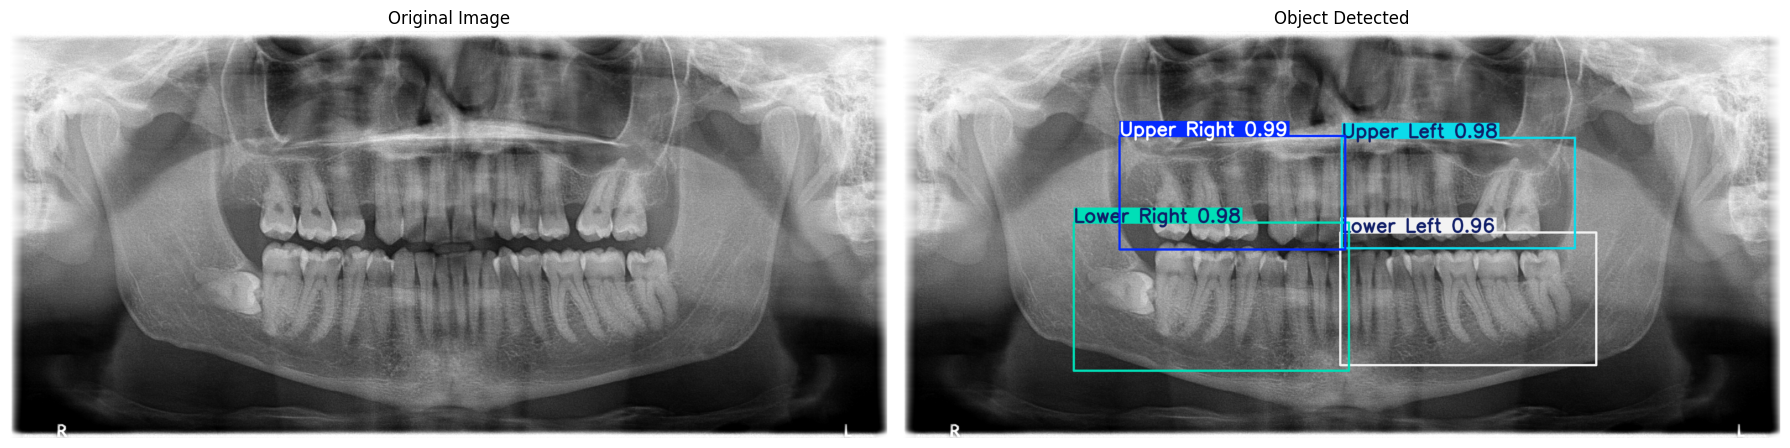

In [8]:
smart_predict(quadrant_model_detection,data_yaml['test'])


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_293.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 114.4ms
Speed: 3.9ms preprocess, 114.4ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Lower Left
Coordinates: [1385.916748046875, 660.7355346679688, 2252.978271484375, 1102.791259765625]
Confidence: %92.0
Class Name: Upper Left
Coordinates: [1388.6815185546875, 343.7506408691406, 2206.249267578125, 737.7495727539062]
Confidence: %92.0
Class Name: Upper Right
Coordinates: [584.3236083984375, 317.65362548828125, 1410.177490234375, 720.4795532226562]
Confidence: %89.0
Class Name: Lower Right
Coordinates: [545.4524536132812, 648.0744018554688, 1401.0006103515625, 1105.7593994140625]
Confidence: %82.0


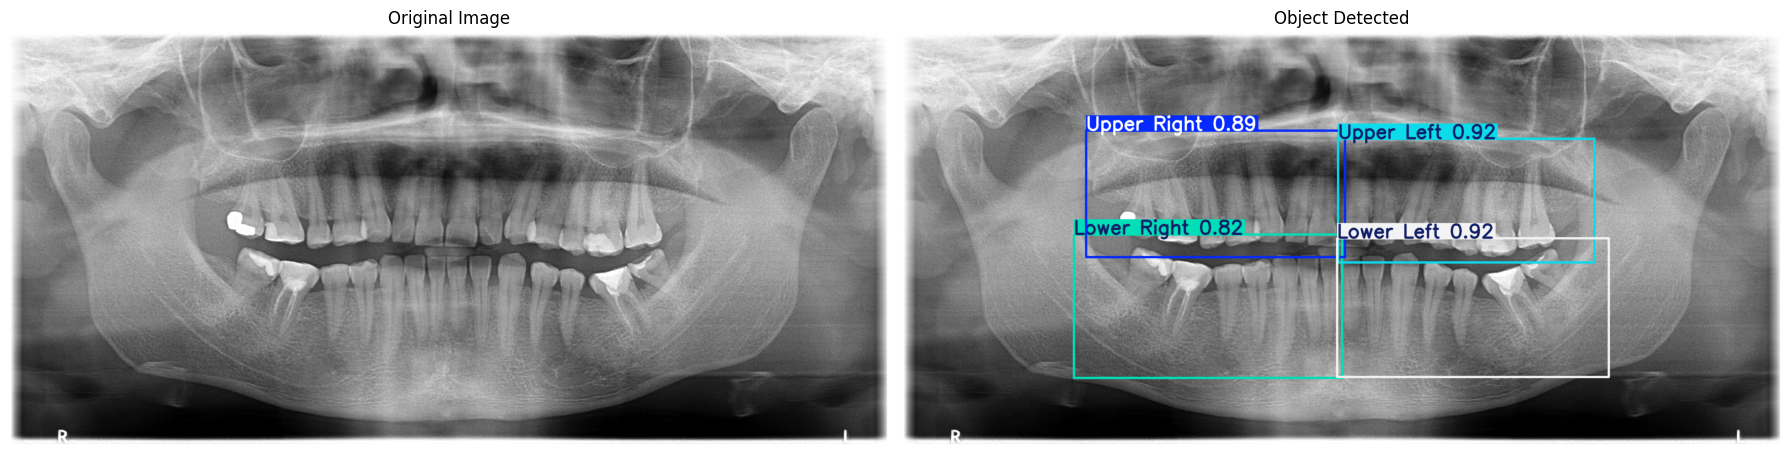

In [15]:
smart_predict(quadrant_model_detection,data_yaml['test'],save_output=True,save_dir=os.path.join(s1_data_output,'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_81.png: 384x768 2 Upper Rights, 1 Upper Left, 1 Lower Left, 1 Lower Right, 119.9ms
Speed: 10.2ms preprocess, 119.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Upper Right
Coordinates: [510.14202880859375, 304.6134033203125, 959.6168212890625, 550.5]
Confidence: %89.0
Class Name: Lower Right
Coordinates: [479.3473815917969, 484.2243957519531, 969.2947998046875, 772.1156616210938]
Confidence: %87.0
Class Name: Lower Left
Coordinates: [962.97216796875, 458.41217041015625, 1417.4288330078125, 765.2840576171875]
Confidence: %75.0
Class Name: Upper Left
Coordinates: [955.8446044921875, 260.2181396484375, 1377.0443115234375, 550.4857788085938]
Confidence: %63.0
Class Name: Upper Right
Coordinates: [957.1932373046875, 262.6518859863281, 1375.1053466796875, 548.7786254882812]
Confidence: %47.0


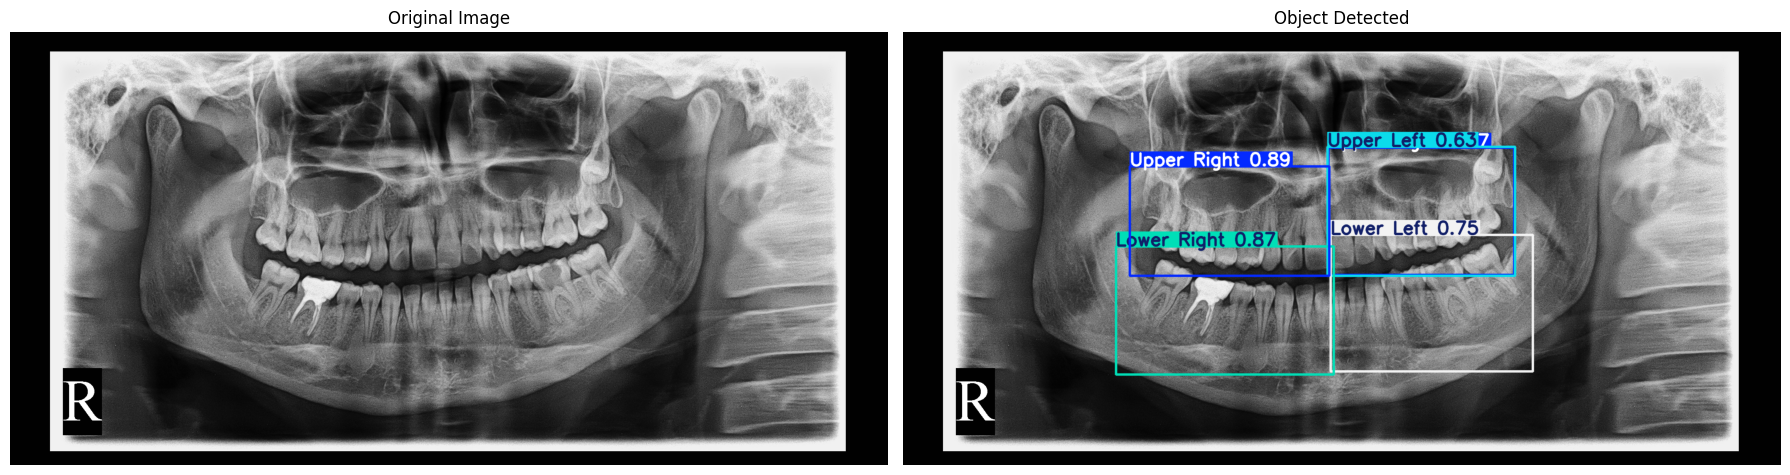

In [17]:
smart_predict(quadrant_model_detection,data_yaml['test'],save_crop_output_image=True,save_dir=os.path.join(s1_data_output,'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_512.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 75.2ms
Speed: 7.3ms preprocess, 75.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Upper Right
Coordinates: [582.27734375, 248.68914794921875, 1371.7080078125, 676.1416625976562]
Confidence: %98.0
Class Name: Lower Right
Coordinates: [515.4501342773438, 559.4495849609375, 1348.3294677734375, 1087.950439453125]
Confidence: %98.0
Class Name: Upper Left
Coordinates: [1356.430419921875, 175.21043395996094, 2185.748779296875, 668.7935180664062]
Confidence: %97.0
Class Name: Lower Left
Coordinates: [1330.3450927734375, 538.5769653320312, 2163.968017578125, 1084.993408203125]
Confidence: %97.0


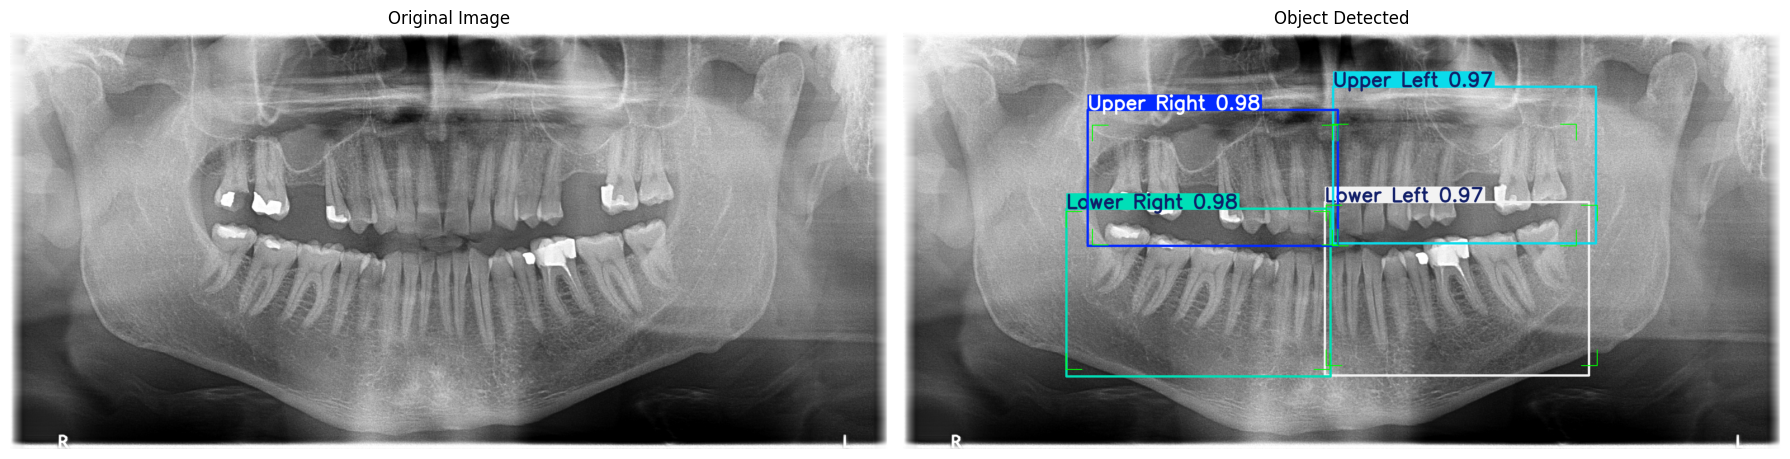

In [9]:
smart_predict(quadrant_model_detection,data_yaml['test'],show_true_boxes=True)


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_76.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 99.4ms
Speed: 23.5ms preprocess, 99.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Upper Left
Coordinates: [1370.99365234375, 400.5506286621094, 2110.138916015625, 779.8068237304688]
Confidence: %99.0
Class Name: Lower Right
Coordinates: [648.6251220703125, 726.8545532226562, 1373.188720703125, 1155.3262939453125]
Confidence: %98.0
Class Name: Upper Right
Coordinates: [623.5604248046875, 415.92291259765625, 1383.498046875, 786.021728515625]
Confidence: %98.0
Class Name: Lower Left
Coordinates: [1358.287353515625, 680.3751831054688, 2192.576416015625, 1117.9698486328125]
Confidence: %97.0


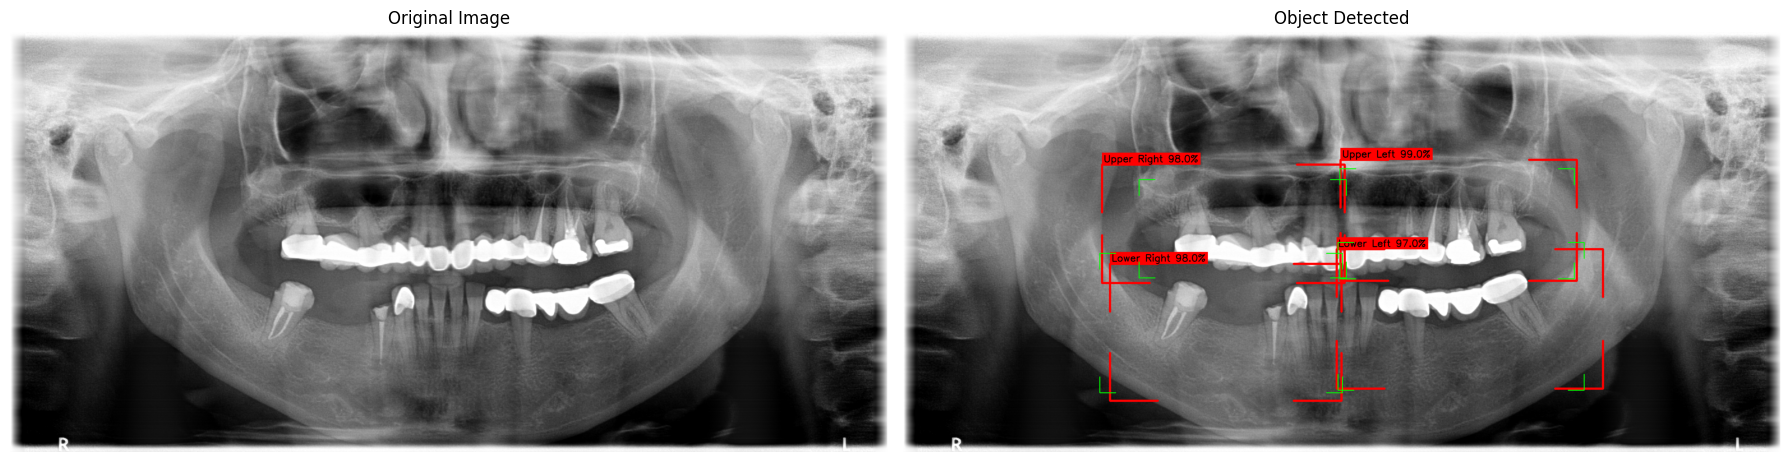

In [10]:
smart_predict(quadrant_model_detection,data_yaml['test'],show_true_boxes=True,apply_custom_draw_box=True)

In [11]:
generate_report(s1_data_output, s1_data_output+'YOLO Training Report (Stage 1).pdf',title='YOLO Training Report (Stage 1)')

Report saved to: ..\Runs\Stage 1\\YOLO Training Report (Stage 1).pdf
